In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import tensorflow as tf
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D, concatenate
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, LearningRateScheduler
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import numpy as np
import pandas as pd
import os
from tensorflow.keras.utils import img_to_array, load_img
import json
from pycocotools.coco import COCO
import matplotlib.pyplot as plt
from PIL import Image
import cv2
from skimage.draw import polygon
from concurrent.futures import ThreadPoolExecutor
from tensorflow.keras.layers import Dropout
from sklearn.metrics import precision_score, recall_score, confusion_matrix, f1_score
from sklearn.metrics import confusion_matrix
import seaborn as sns
from tensorflow.keras import layers, models
import albumentations as A


In [ ]:
# Set paths
train_image_dir = '/content/drive/MyDrive/archive/train'
train_mask_path = '/content/drive/MyDrive/archive/train/_annotations.coco.json'
val_image_dir = '/content/drive/MyDrive/archive/valid'
val_mask_path = '/content/drive/MyDrive/archive/valid/_annotations.coco.json'
test_image_dir = '/content/drive/MyDrive/archive/test'
test_mask_path = '/content/drive/MyDrive/archive/test/_annotations.coco.json'


In [ ]:
IMG_HEIGHT = 128
IMG_WIDTH = 128
input_size = (128, 128, 3)
batch_size = 16
learning_rate = 1e-4

Total number of image files in /content/drive/MyDrive/archive/train: 1502
Total number of image files in /content/drive/MyDrive/archive/valid: 429
Total number of image files in /content/drive/MyDrive/archive/test: 215


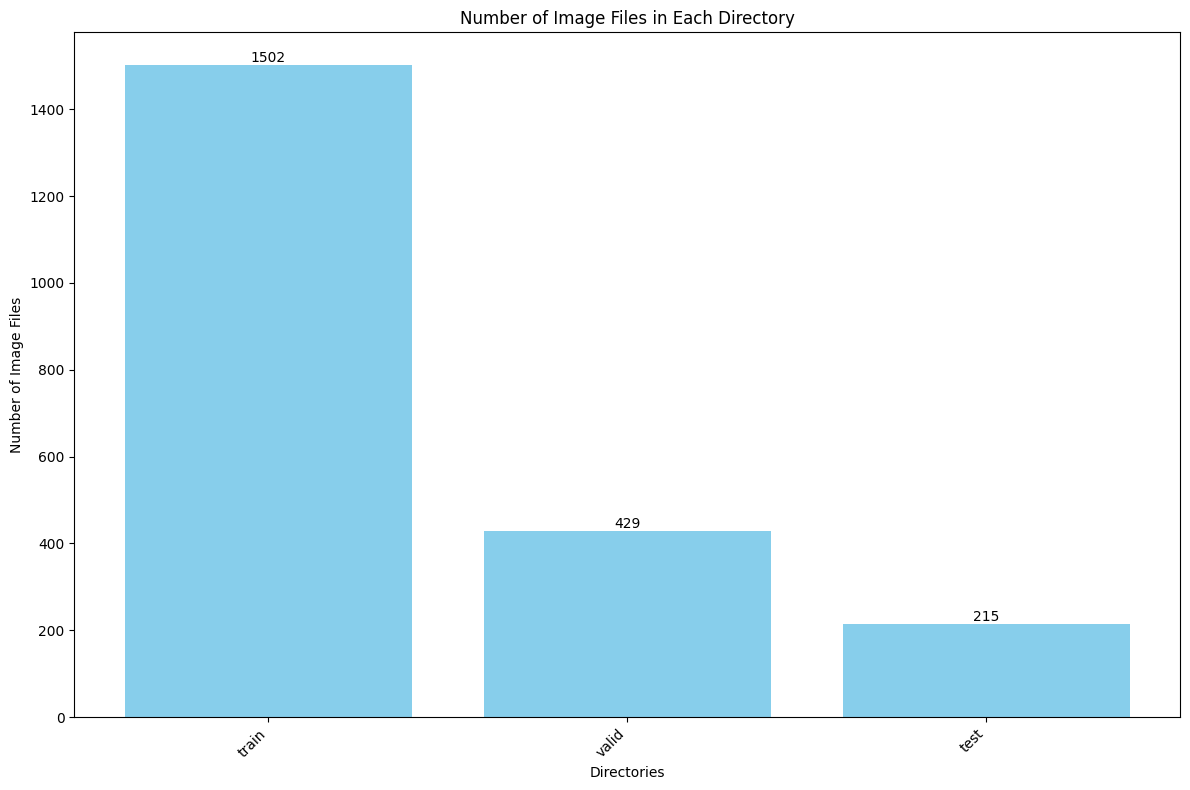

In [ ]:

# Function to count image files in a directory
def count_image_files(directory):
    # Supported image extensions
    image_extensions = ['.png', '.jpg', '.jpeg']

    # Dictionary to store count of each type
    image_count = {ext: 0 for ext in image_extensions}
    total_images = 0

    # Walk through directory
    for root, dirs, files in os.walk(directory):
        for file in files:
            # Get file extension
            ext = os.path.splitext(file)[1].lower()
            if ext in image_extensions:
                image_count[ext] += 1
                total_images += 1

    return total_images

# Function to plot the image counts
def plot_image_counts(image_counts, directory_names):
    plt.figure(figsize=(12, 8))
    bars = plt.bar(directory_names, image_counts, color='skyblue')
    plt.xlabel('Directories')
    plt.ylabel('Number of Image Files')
    plt.title('Number of Image Files in Each Directory')
    plt.xticks(rotation=45, ha='right')
    # Add counts above the bars
    for bar in bars:
        yval = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2.0, yval, int(yval), ha='center', va='bottom')
    plt.tight_layout()
    plt.show()

# List of directories
directories = [
    train_image_dir, val_image_dir, test_image_dir
]

# Get directory names from paths
directory_names = [os.path.basename(directory) for directory in directories]

# Count image files in each directory
image_counts = []
for directory in directories:
    image_count = count_image_files(directory)
    image_counts.append(image_count)
    print(f"Total number of image files in {directory}: {image_count}")

# Plot the results
plot_image_counts(image_counts, directory_names)


In [ ]:
def create_mask_from_annotations(annotations, height, width):
    mask = np.zeros((height, width), dtype=np.uint8)
    for annotation in annotations:
        for seg in annotation['segmentation']:
            poly = np.array(seg).reshape((len(seg) // 2, 2))
            rr, cc = polygon(poly[:, 1], poly[:, 0], (height, width))
            mask[rr, cc] = 1
    return mask


def process_image(img_info, image_dir, coco):
    img_path = os.path.join(image_dir, img_info['file_name'])
    img = cv2.imread(img_path)
    if img is None:
        print(f"Warning: Unable to read image at {img_path}")
        return None, None

    img = cv2.resize(img, (IMG_WIDTH, IMG_HEIGHT))
    img = img / 255.0

    ann_ids = coco.getAnnIds(imgIds=img_info['id'])
    annotations = coco.loadAnns(ann_ids)

    mask = create_mask_from_annotations(annotations, img_info['height'], img_info['width'])
    mask = cv2.resize(mask, (IMG_WIDTH, IMG_HEIGHT))
    mask = mask / 255.0

    mask = cv2.resize(mask, (IMG_WIDTH, IMG_HEIGHT))
    mask = (mask > 0).astype(np.float32)

    return img, mask

def load_images_and_masks(image_dir, mask_path, img_height=IMG_HEIGHT, img_width=IMG_WIDTH):
    coco = COCO(mask_path)
    images = []
    masks = []

    img_ids = coco.getImgIds()
    img_infos = coco.loadImgs(img_ids)

    # Use ThreadPoolExecutor to process images in parallel
    with ThreadPoolExecutor() as executor:
        results = list(executor.map(lambda img_info: process_image(img_info, image_dir, coco), img_infos))

    for img, mask in results:
        if img is not None and mask is not None:
            images.append(img)
            masks.append(mask)

    images = np.array(images)
    masks = np.array(masks)
    masks = np.expand_dims(masks, axis=-1)  # Add channel dimension

    return images, masks



# Load annotations
train_image, train_mask = load_images_and_masks(train_image_dir, train_mask_path)
val_image, val_mask = load_images_and_masks(val_image_dir,val_mask_path)
test_image, test_mask = load_images_and_masks(test_image_dir, test_mask_path)

loading annotations into memory...
Done (t=6.41s)
creating index...
index created!
loading annotations into memory...
Done (t=2.04s)
creating index...
index created!
loading annotations into memory...
Done (t=1.63s)
creating index...
index created!


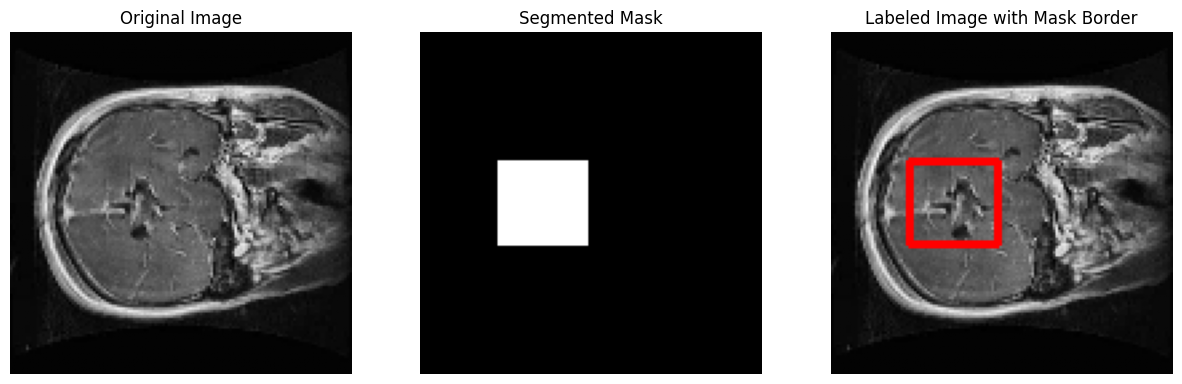

In [ ]:
def plot_image_mask_and_labeled(img, mask):
    # Ensure the mask has the correct shape: (height, width)
    if len(mask.shape) == 3 and mask.shape[2] == 1:  # If mask has shape (height, width, 1)
        mask = mask.squeeze(axis=-1)  # Convert to (height, width)

    # If the image is grayscale (2D), convert it to a 3D RGB image
    if len(img.shape) == 2 or img.shape[2] == 1:
        img = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)

    # Create a labeled image by overlaying the border of the mask onto the original image
    labeled_img = img.copy()

    # Find contours in the mask
    contours, _ = cv2.findContours(mask.astype(np.uint8), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    # Draw contours on the image
    cv2.drawContours(labeled_img, contours, -1, (255, 0, 0), thickness=2)  # Red color, 2-pixel thickness

    plt.figure(figsize=(15, 5))

    # Plot the original image
    plt.subplot(1, 3, 1)
    plt.imshow(img)
    plt.title("Original Image")
    plt.axis('off')

    # Plot the mask
    plt.subplot(1, 3, 2)
    plt.imshow(mask, cmap='gray')
    plt.title("Segmented Mask")
    plt.axis('off')

    # Plot the labeled image with the mask border
    plt.subplot(1, 3, 3)
    plt.imshow(labeled_img)
    plt.title("Labeled Image with Mask Border")
    plt.axis('off')

    plt.show()


# Sample usage:
sample_idx = 0  # Change index to plot different samples
plot_image_mask_and_labeled(train_image[sample_idx], train_mask[sample_idx])


In [ ]:
# Define the U-Net model
def unet_model(input_size=(128, 128, 3)):
    inputs = Input(input_size)

    # Encoder
    c1 = Conv2D(64, (3, 3), activation='relu', padding='same')(inputs)
    c1 = Conv2D(64, (3, 3), activation='relu', padding='same')(c1)
    p1 = MaxPooling2D((2, 2))(c1)

    c2 = Conv2D(128, (3, 3), activation='relu', padding='same')(p1)
    c2 = Conv2D(128, (3, 3), activation='relu', padding='same')(c2)
    p2 = MaxPooling2D((2, 2))(c2)

    c3 = Conv2D(256, (3, 3), activation='relu', padding='same')(p2)
    c3 = Conv2D(256, (3, 3), activation='relu', padding='same')(c3)
    p3 = MaxPooling2D((2, 2))(c3)

    c4 = Conv2D(512, (3, 3), activation='relu', padding='same')(p3)
    c4 = Conv2D(512, (3, 3), activation='relu', padding='same')(c4)
    p4 = MaxPooling2D((2, 2))(c4)

    # Bottleneck
    c5 = Conv2D(1024, (3, 3), activation='relu', padding='same')(p4)
    c5 = Dropout(0.5)(c5)  # Adding dropout
    c5 = Conv2D(1024, (3, 3), activation='relu', padding='same')(c5)

    # Decoder
    u6 = UpSampling2D((2, 2))(c5)
    u6 = concatenate([u6, c4])
    c6 = Conv2D(512, (3, 3), activation='relu', padding='same')(u6)
    c6 = Conv2D(512, (3, 3), activation='relu', padding='same')(c6)

    u7 = UpSampling2D((2, 2))(c6)
    u7 = concatenate([u7, c3])
    c7 = Conv2D(256, (3, 3), activation='relu', padding='same')(u7)
    c7 = Conv2D(256, (3, 3), activation='relu', padding='same')(c7)

    u8 = UpSampling2D((2, 2))(c7)
    u8 = concatenate([u8, c2])
    c8 = Conv2D(128, (3, 3), activation='relu', padding='same')(u8)
    c8 = Conv2D(128, (3, 3), activation='relu', padding='same')(c8)

    u9 = UpSampling2D((2, 2))(c8)
    u9 = concatenate([u9, c1])
    c9 = Conv2D(64, (3, 3), activation='relu', padding='same')(u9)
    c9 = Conv2D(64, (3, 3), activation='relu', padding='same')(c9)

    outputs = Conv2D(1, (1, 1), activation='sigmoid')(c9)

    model = Model(inputs=[inputs], outputs=[outputs], name='UNet_Model')
    return model


In [ ]:
# Instantiate the model
UNETmodel = unet_model(input_size=input_size)

UNETmodel.summary()

# Compile the model
optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)
UNETmodel.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])


Model: "UNet_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3             │ (None, 128, 128, 3)    │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_23 (Conv2D)        │ (None, 128, 128, 64)   │          1,792 │ input_layer_3[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_24 (Conv2D)        │ (None, 128, 128, 64)   │         36,928 │ conv2d_23[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling2d_4           │ (None, 64, 64, 64)     │              0 │ conv2d_24[0][0]        │
│ (MaxPooling2D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_25 (Conv2D)        │ (None, 64, 64, 128)    │         73,856 │ max_pooling2d_4[0][0]  │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_26 (Conv2D)        │ (None, 64, 64, 128)    │        147,584 │ conv2d_25[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling2d_5           │ (None, 32, 32, 128)    │              0 │ conv2d_26[0][0]        │
│ (MaxPooling2D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_27 (Conv2D)        │ (None, 32, 32, 256)    │        295,168 │ max_pooling2d_5[0][0]  │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_28 (Conv2D)        │ (None, 32, 32, 256)    │        590,080 │ conv2d_27[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling2d_6           │ (None, 16, 16, 256)    │              0 │ conv2d_28[0][0]        │
│ (MaxPooling2D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_29 (Conv2D)        │ (None, 16, 16, 512)    │      1,180,160 │ max_pooling2d_6[0][0]  │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_30 (Conv2D)        │ (None, 16, 16, 512)    │      2,359,808 │ conv2d_29[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling2d_7           │ (None, 8, 8, 512)      │              0 │ conv2d_30[0][0]        │
│ (MaxPooling2D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_31 (Conv2D)        │ (None, 8, 8, 1024)     │      4,719,616 │ max_pooling2d_7[0][0]  │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dropout (Dropout)         │ (None, 8, 8, 1024)     │              0 │ conv2d_31[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_32 (Conv2D)        │ (None, 8, 8, 1024)     │      9,438,208 │ dropout[0][0]          │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ up_sampling2d_1           │ (None, 16, 16, 1024)   │              0 │ conv2d_32[0][0]        │
│ (UpSampling2D)       

 Total params: 31,378,945 (119.70 MB)

 Trainable params: 31,378,945 (119.70 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Callbacks
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
model_checkpoint = ModelCheckpoint('unet_best_model.keras', save_best_only=True)

In [ ]:
UNethistory = UNETmodel.fit(
    train_image, train_mask,
    validation_data=(val_image, val_mask),
    epochs=30,
    callbacks=[early_stopping, model_checkpoint]
)

Epoch 1/30
47/47 ━━━━━━━━━━━━━━━━━━━━ 157s 2s/step - accuracy: 0.8799 - loss: 0.3944 - val_accuracy: 0.9633 - val_loss: 0.1166
Epoch 2/30
47/47 ━━━━━━━━━━━━━━━━━━━━ 97s 1s/step - accuracy: 0.9635 - loss: 0.1119 - val_accuracy: 0.9633 - val_loss: 0.1086
Epoch 3/30
47/47 ━━━━━━━━━━━━━━━━━━━━ 87s 1s/step - accuracy: 0.9636 - loss: 0.1047 - val_accuracy: 0.9633 - val_loss: 0.1020
Epoch 4/30
47/47 ━━━━━━━━━━━━━━━━━━━━ 79s 1s/step - accuracy: 0.9623 - loss: 0.1034 - val_accuracy: 0.9633 - val_loss: 0.1010
Epoch 5/30
47/47 ━━━━━━━━━━━━━━━━━━━━ 80s 1s/step - accuracy: 0.9631 - loss: 0.0970 - val_accuracy: 0.9633 - val_loss: 0.0924
Epoch 6/30
47/47 ━━━━━━━━━━━━━━━━━━━━ 65s 661ms/step - accuracy: 0.9641 - loss: 0.0884 - val_accuracy: 0.9633 - val_loss: 0.0904
Epoch 7/30
47/47 ━━━━━━━━━━━━━━━━━━━━ 59s 1s/step - accuracy: 0.9638 - loss: 0.0911 - val_accuracy: 0.9678 - val_loss: 0.0833
Epoch 8/30
47/47 ━━━━━━━━━━━━━━━━━━━━ 78s 980ms/step - accuracy: 0.9680 - loss: 0.0823 - val_accuracy: 0.9694 - va

In [ ]:
# evaluate on the test set
UNettest_loss, UNettest_accuracy = UNETmodel.evaluate(test_image, test_mask, verbose=1)
print(f"U-Net model Test Loss: {UNettest_loss}")
print(f"U-Net model Test Accuracy: {UNettest_accuracy}")

7/7 ━━━━━━━━━━━━━━━━━━━━ 9s 1s/step - accuracy: 0.9799 - loss: 0.0537
U-Net model Test Loss: 0.052164316177368164
U-Net model Test Accuracy: 0.9804009199142456


In [ ]:
def plot_masked_images(masks):

  # Function to display images
  def display_images(images, titles=None, cmap=None):
    n = len(images)
    plt.figure(figsize=(20, 10))
    for i in range(n):
        plt.subplot(1, n, i + 1)
        plt.imshow(images[i], cmap=cmap)
        if titles:
            plt.title(titles[i])
        plt.axis('off')
    plt.show()



  # Display some test images with their true and predicted masks
  num_images_to_display = 5
  indices = np.random.choice(len(test_image), num_images_to_display, replace=False)

  for i in indices:
    test_img = test_image[i]
    true_mask = test_mask[i].squeeze()
    predicted_mask = masks[i].squeeze()

    display_images(
        [test_img, true_mask, predicted_mask],
        titles=['Test Image', 'True Mask', 'Predicted Mask'],
        cmap='gray'
    )


In [ ]:
# Predict masks on the test set
UNetpredicted_masks = UNETmodel.predict(test_image)

# Threshold the predicted masks
UNetpredicted_masks = (UNetpredicted_masks > 0.5).astype(np.uint8)

7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 238ms/step


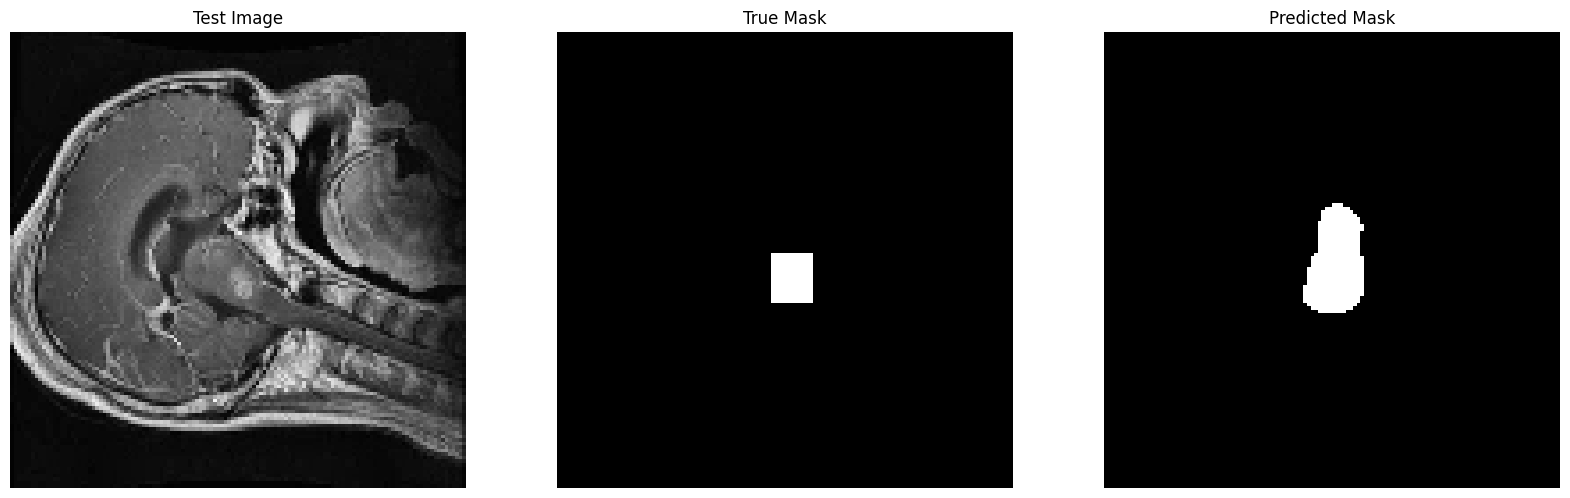

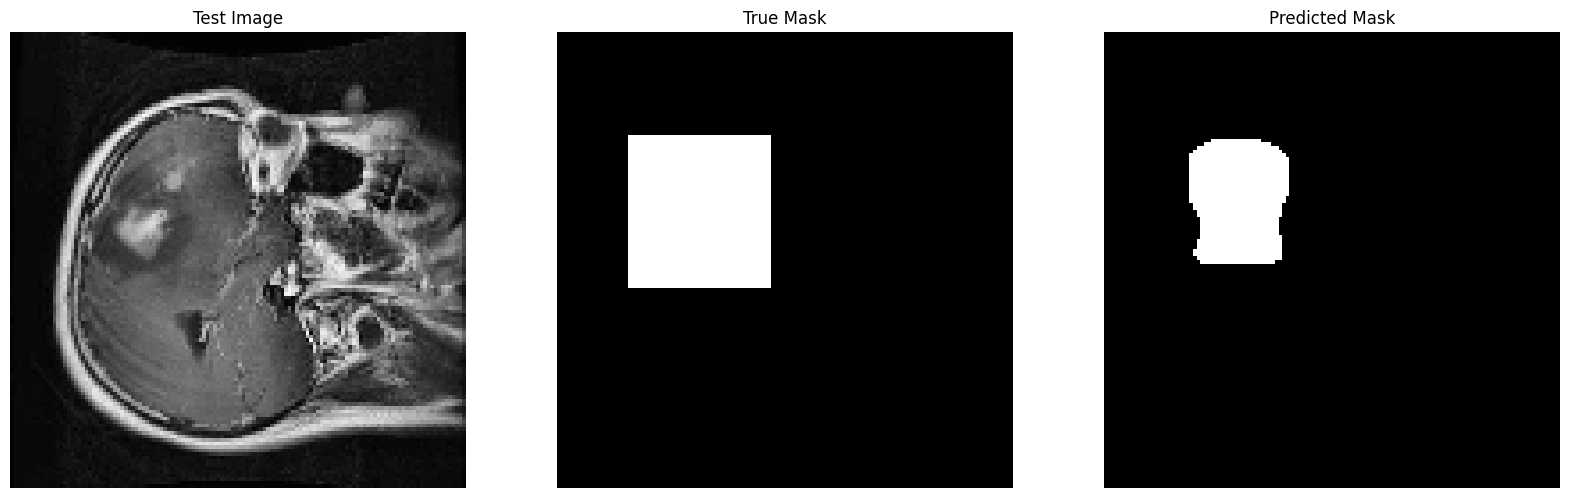

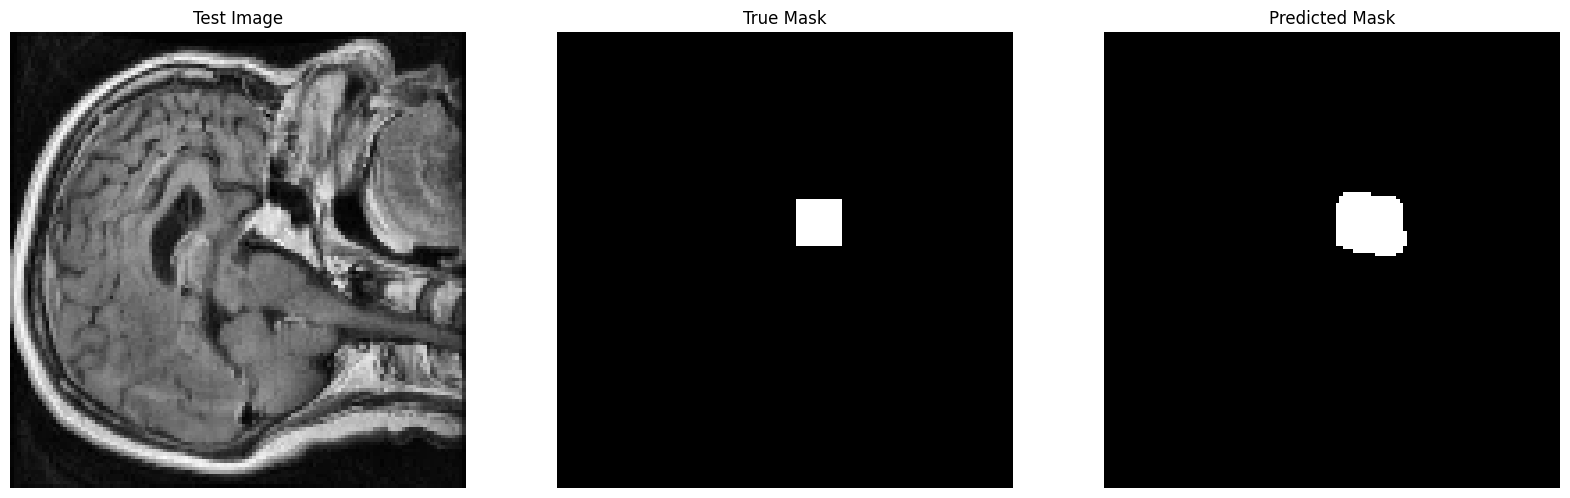

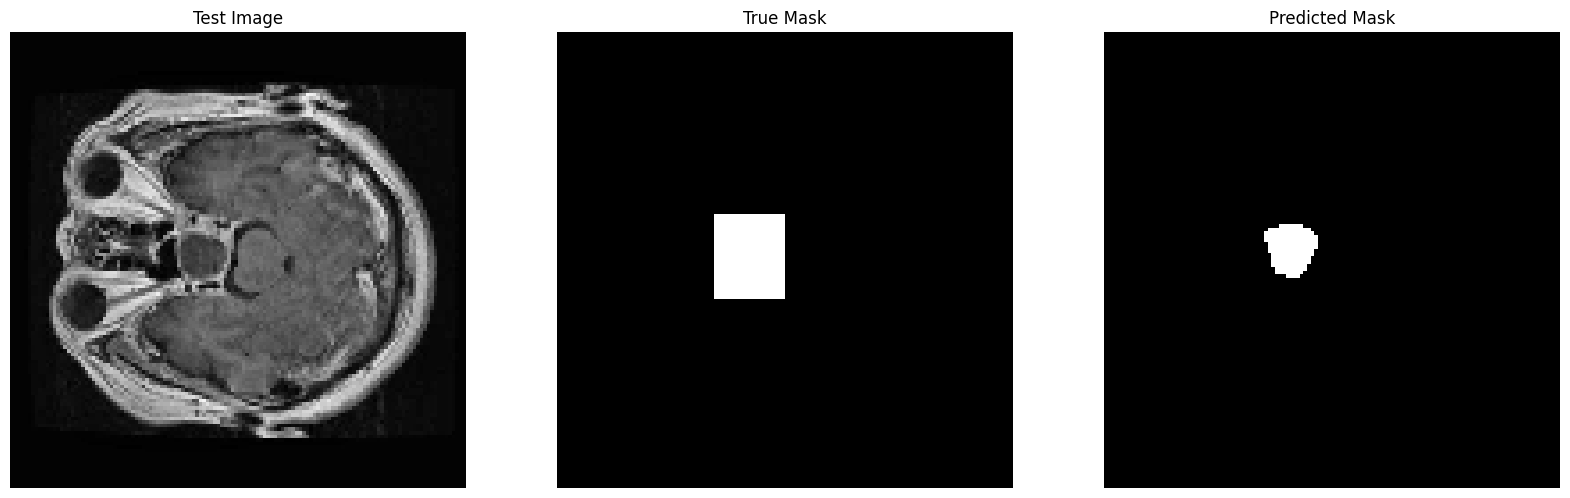

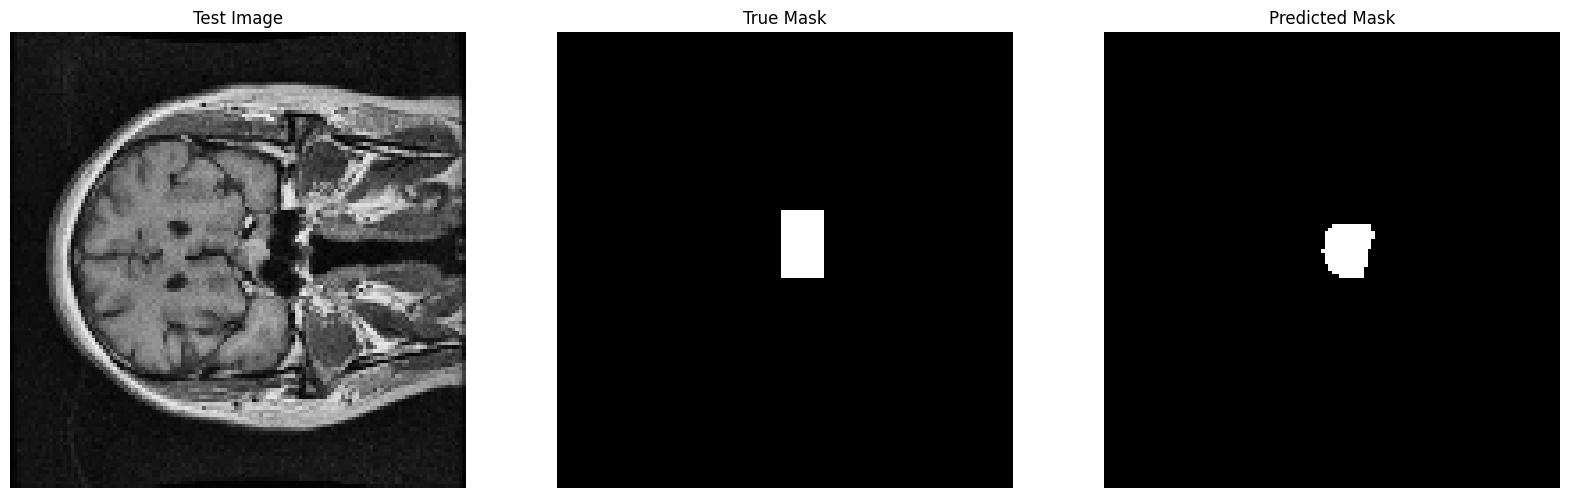

In [ ]:
plot_masked_images(UNetpredicted_masks)

In [ ]:
def plot_accuracy_loss_graph(history):
  #  Plot the loss graph
  plt.figure(figsize=(12, 6))

  # Plot training & validation loss values
  plt.subplot(1, 2, 1)
  plt.plot(history.history['loss'], label='Train Loss')
  plt.plot(history.history['val_loss'], label='Validation Loss')
  plt.title('Model Loss')
  plt.xlabel('Epoch')
  plt.ylabel('Loss')
  plt.legend(loc='upper right')

  #  Plot the accuracy graph
  # Plot training & validation accuracy values
  plt.subplot(1, 2, 2)
  plt.plot(history.history['accuracy'], label='Train Accuracy')
  plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
  plt.title('Model Accuracy')
  plt.xlabel('Epoch')
  plt.ylabel('Accuracy')
  plt.legend(loc='upper left')

  # Display the plots
  plt.tight_layout()
  plt.show()


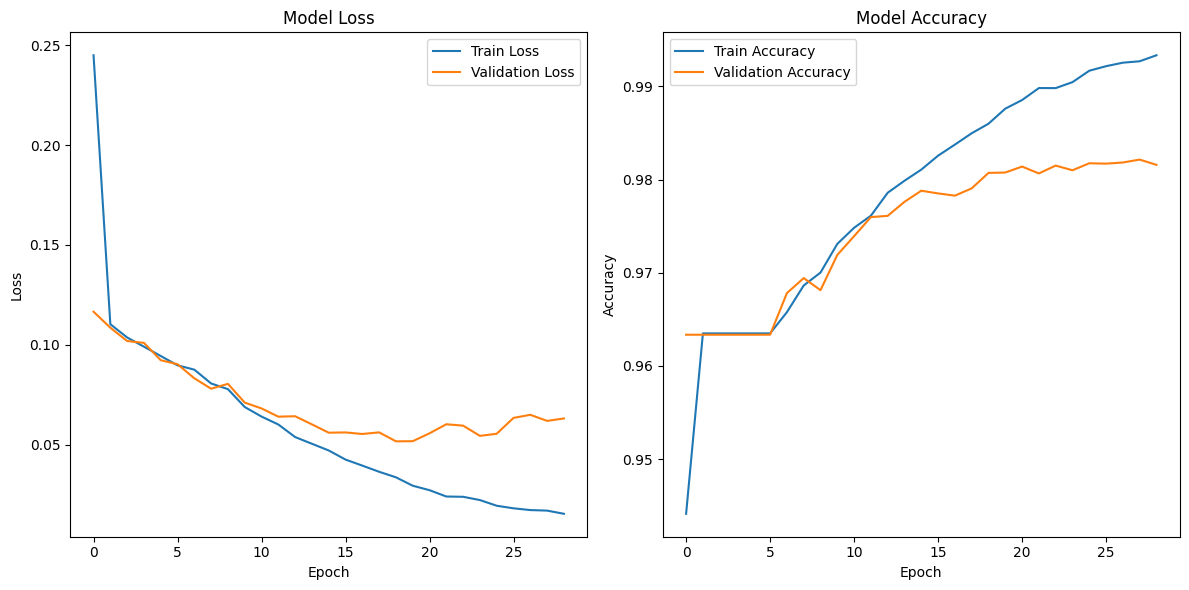

In [ ]:
plot_accuracy_loss_graph(UNethistory)

In [ ]:
image_label = "Test Image"  # Replace with actual image description or index
mask_label = "Mask"

def calculate_evaluation_matrix(masks):
  # Flatten the true masks
  y_true = test_mask.reshape(-1)  # Flatten to 1D array

  # Flatten the predicted masks and apply threshold
  y_pred = (masks > 0.5).astype(np.uint8).reshape(-1)  # Flatten to 1D array



  # Check if the shapes match
  if y_true.shape != y_pred.shape:
      raise ValueError(f"Shape mismatch: y_true has shape {y_true.shape}, but y_pred has shape {y_pred.shape}")

  # Compute the confusion matrix
  conf_matrix = confusion_matrix(y_true, y_pred)

  # Visualize the confusion matrix
  plt.figure(figsize=(8, 6))
  sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
              xticklabels=[f'Predicted {mask_label}', f'Predicted {image_label}'],
              yticklabels=[f'True {mask_label}', f'True {image_label}'])
  plt.xlabel('Predicted Labels')
  plt.ylabel('True Labels')
  plt.title('Confusion Matrix')
  plt.show()

  # Extract TP, FP, FN from the confusion matrix
  TN, FP, FN, TP = conf_matrix.ravel()

  # Calculate precision and recall manually
  precision = TP / (TP + FP)
  recall = TP / (TP + FN)
  f1 = f1_score(y_true, y_pred)

  print(f'Precision: {precision}')
  print(f'Recall: {recall}')
  print(f'F1 Score: {f1:.4f}')

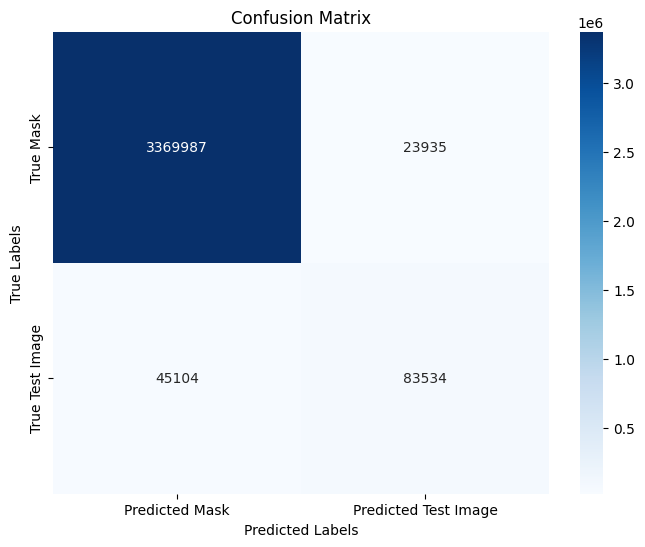

Precision: 0.7772846123068048
Recall: 0.6493726581569987
F1 Score: 0.7076


In [ ]:
calculate_evaluation_matrix(UNetpredicted_masks)

In [ ]:
def conv2d_block(x, filters, kernel_size=3, padding='same', activation='relu'):
    x = layers.Conv2D(filters, kernel_size, padding=padding)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation(activation)(x)
    return x

def atrous_spatial_pyramid_pooling(x):
    # ASPP block
    b4 = layers.Conv2D(256, (1, 1), padding='same', activation='relu')(x)
    b4 = layers.BatchNormalization()(b4)

    b6 = layers.Conv2D(256, (3, 3), dilation_rate=(6, 6), padding='same', activation='relu')(x)
    b6 = layers.BatchNormalization()(b6)

    b12 = layers.Conv2D(256, (3, 3), dilation_rate=(12, 12), padding='same', activation='relu')(x)
    b12 = layers.BatchNormalization()(b12)

    b18 = layers.Conv2D(256, (3, 3), dilation_rate=(18, 18), padding='same', activation='relu')(x)
    b18 = layers.BatchNormalization()(b18)

    # Image pooling branch
    b_pool = layers.GlobalAveragePooling2D()(x)
    b_pool = layers.Reshape((1, 1, b_pool.shape[-1]))(b_pool)
    b_pool = layers.Conv2D(256, (1, 1), padding='same', activation='relu')(b_pool)
    b_pool = layers.BatchNormalization()(b_pool)
    b_pool = layers.UpSampling2D(size=(x.shape[1], x.shape[2]), interpolation='bilinear')(b_pool)

    # Concatenate all branches
    x = layers.Concatenate()([b4, b6, b12, b18, b_pool])
    x = layers.Conv2D(256, (1, 1), padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    return x

def deeplabv3_model(input_shape, n_classes):
    inputs = tf.keras.Input(shape=input_shape)

    # Backbone: Xception
    backbone = tf.keras.applications.Xception(input_shape=input_shape, include_top=False, weights='imagenet')
    x = backbone(inputs, training=False)

    # ASPP
    x = atrous_spatial_pyramid_pooling(x)

    # Decoder: Upsampling to match input size
    x = layers.Conv2DTranspose(128, (3, 3), strides=(2, 2), padding='same', activation='relu')(x)
    x = conv2d_block(x, 128)

    x = layers.Conv2DTranspose(64, (3, 3), strides=(2, 2), padding='same', activation='relu')(x)
    x = conv2d_block(x, 64)

    # Final upsampling to exact size
    x = layers.Conv2DTranspose(n_classes, (16, 16), strides=(8, 8), padding='same')(x)
    outputs = layers.Activation('sigmoid')(x)

    model = models.Model(inputs, outputs, name='DeepLabv3_model')
    return model

In [ ]:
DeepLmodel = deeplabv3_model((128, 128, 3), 1)
DeepLmodel.summary()

83683744/83683744 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "DeepLabv3_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)  │ (None, 128, 128, 3)    │              0 │ -                      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ xception (Functional)     │ (None, 4, 4, 2048)     │     20,861,480 │ input_layer[0][0]      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ global_average_pooling2d  │ (None, 2048)           │              0 │ xception[0][0]         │
│ (GlobalAveragePooling2D)  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ reshape (Reshape)         │ (None, 1, 1, 2048)     │              0 │ global_average_poolin… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_8 (Conv2D)         │ (None, 1, 1, 256)      │        524,544 │ reshape[0][0]          │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_4 (Conv2D)         │ (None, 4, 4, 256)      │        524,544 │ xception[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_5 (Conv2D)         │ (None, 4, 4, 256)      │      4,718,848 │ xception[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_6 (Conv2D)         │ (None, 4, 4, 256)      │      4,718,848 │ xception[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_7 (Conv2D)         │ (None, 4, 4, 256)      │      4,718,848 │ xception[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_8     │ (None, 1, 1, 256)      │          1,024 │ conv2d_8[0][0]         │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_4     │ (None, 4, 4, 256)      │          1,024 │ conv2d_4[0][0]         │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_5     │ (None, 4, 4, 256)      │          1,024 │ conv2d_5[0][0]         │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_6     │ (None, 4, 4, 256)      │          1,024 │ conv2d_6[0][0]         │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_7     │ (None, 4, 4, 256)      │          1,024 │ conv2d_7[0][0]         │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ up_sampling2d             │ (None, 4, 4, 256)      │              0 │ batch_normalization_8… │
│ (UpSampling2D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ concatenate (Concatenate) │ (None, 4, 4, 1280)     │              0 │ batch_normalization_4… │
│                      

 Total params: 36,971,689 (141.04 MB)

 Trainable params: 36,913,705 (140.81 MB)

 Non-trainable params: 57,984 (226.50 KB)

In [ ]:
# Define custom loss function
def dice_coefficient(y_true, y_pred, smooth=1):
    y_true_f = tf.keras.backend.flatten(y_true)
    y_pred_f = tf.keras.backend.flatten(y_pred)
    intersection = tf.keras.backend.sum(y_true_f * y_pred_f)
    return (2. * intersection + smooth) / (tf.keras.backend.sum(y_true_f) + tf.keras.backend.sum(y_pred_f) + smooth)

def dice_loss(y_true, y_pred):
    return 1 - dice_coefficient(y_true, y_pred)

In [ ]:
# Compile the model
DeepLmodel.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss=dice_loss,  # or 'categorical_crossentropy' for multi-class
    metrics=['accuracy', dice_coefficient]
)

In [ ]:
BATCH_SIZE = 16
EPOCHS = 30

DeepLhistory = DeepLmodel.fit(
    train_image, train_mask,
    validation_data=(val_image, val_mask),
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
        tf.keras.callbacks.ModelCheckpoint('deeplabv3_plus_best_model.keras', save_best_only=True)
    ]
)

Epoch 1/30
94/94 ━━━━━━━━━━━━━━━━━━━━ 215s 1s/step - accuracy: 0.4207 - dice_coefficient: 0.0814 - loss: 0.9186 - val_accuracy: 0.7485 - val_dice_coefficient: 0.0963 - val_loss: 0.9038
Epoch 2/30
94/94 ━━━━━━━━━━━━━━━━━━━━ 46s 343ms/step - accuracy: 0.7390 - dice_coefficient: 0.1187 - loss: 0.8813 - val_accuracy: 0.8790 - val_dice_coefficient: 0.1095 - val_loss: 0.8905
Epoch 3/30
94/94 ━━━━━━━━━━━━━━━━━━━━ 40s 327ms/step - accuracy: 0.8065 - dice_coefficient: 0.1311 - loss: 0.8689 - val_accuracy: 0.9013 - val_dice_coefficient: 0.1365 - val_loss: 0.8636
Epoch 4/30
94/94 ━━━━━━━━━━━━━━━━━━━━ 49s 419ms/step - accuracy: 0.8675 - dice_coefficient: 0.1426 - loss: 0.8574 - val_accuracy: 0.8994 - val_dice_coefficient: 0.1527 - val_loss: 0.8473
Epoch 5/30
94/94 ━━━━━━━━━━━━━━━━━━━━ 33s 330ms/step - accuracy: 0.8945 - dice_coefficient: 0.1522 - loss: 0.8478 - val_accuracy: 0.8996 - val_dice_coefficient: 0.1682 - val_loss: 0.8319
Epoch 6/30
94/94 ━━━━━━━━━━━━━━━━━━━━ 41s 329ms/step - accuracy: 0.

In [ ]:
#test_image, test_mask = preprocess_data(test_image, test_mask, target_size=(IMG_HEIGHT, IMG_WIDTH))
DeepLtest_loss, DeepLtest_accuracy, DeepLdice_loss = DeepLmodel.evaluate(test_image, test_mask, verbose=1)
print(f"Test Loss: {DeepLtest_loss}")
print(f"Test Accuracy: {DeepLtest_accuracy}")


7/7 ━━━━━━━━━━━━━━━━━━━━ 25s 2s/step - accuracy: 0.9817 - dice_coefficient: 0.7490 - loss: 0.2505
Test Loss: 0.25438109040260315
Test Accuracy: 0.9822660088539124


In [ ]:
# Predict masks on the test set
DeepLpredicted_masks = DeepLmodel.predict(test_image)

# Apply a threshold to binarize the predicted masks
threshold = 0.5
DeepLpredicted_masks = (DeepLpredicted_masks > threshold).astype(np.uint8)


7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 99ms/step


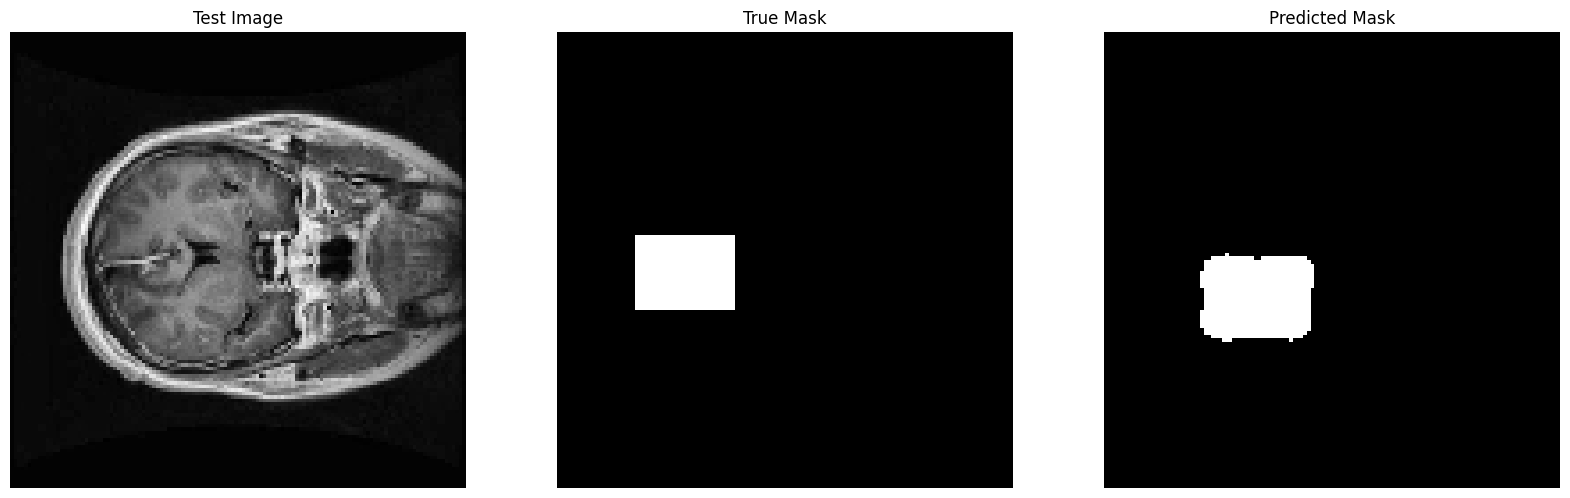

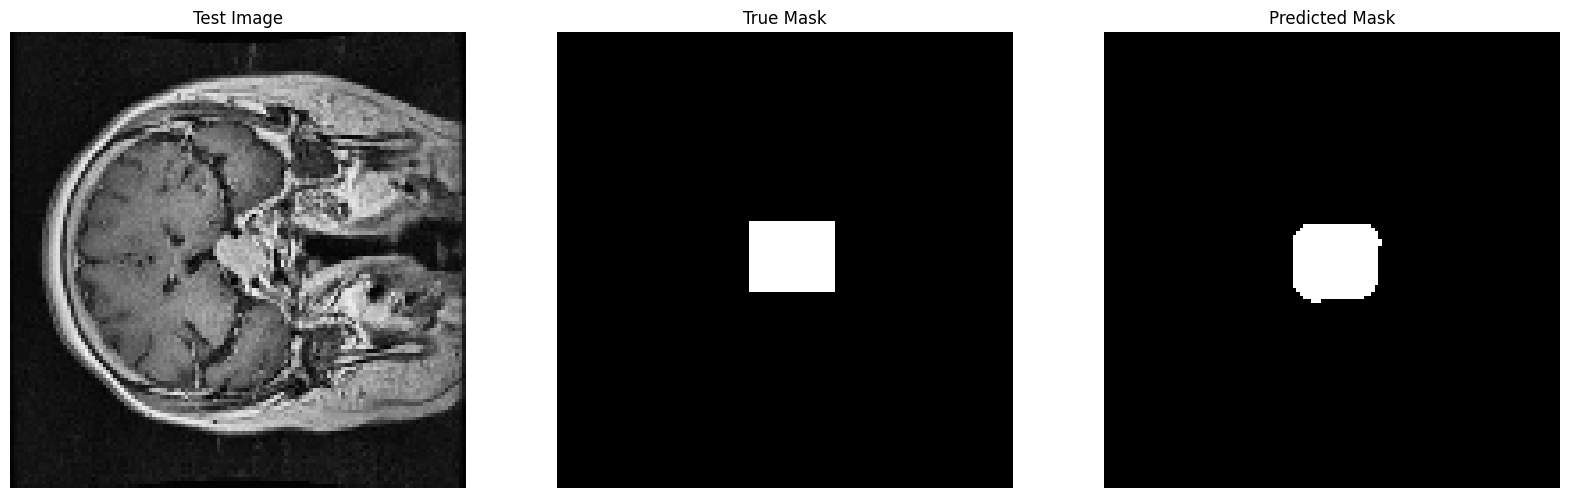

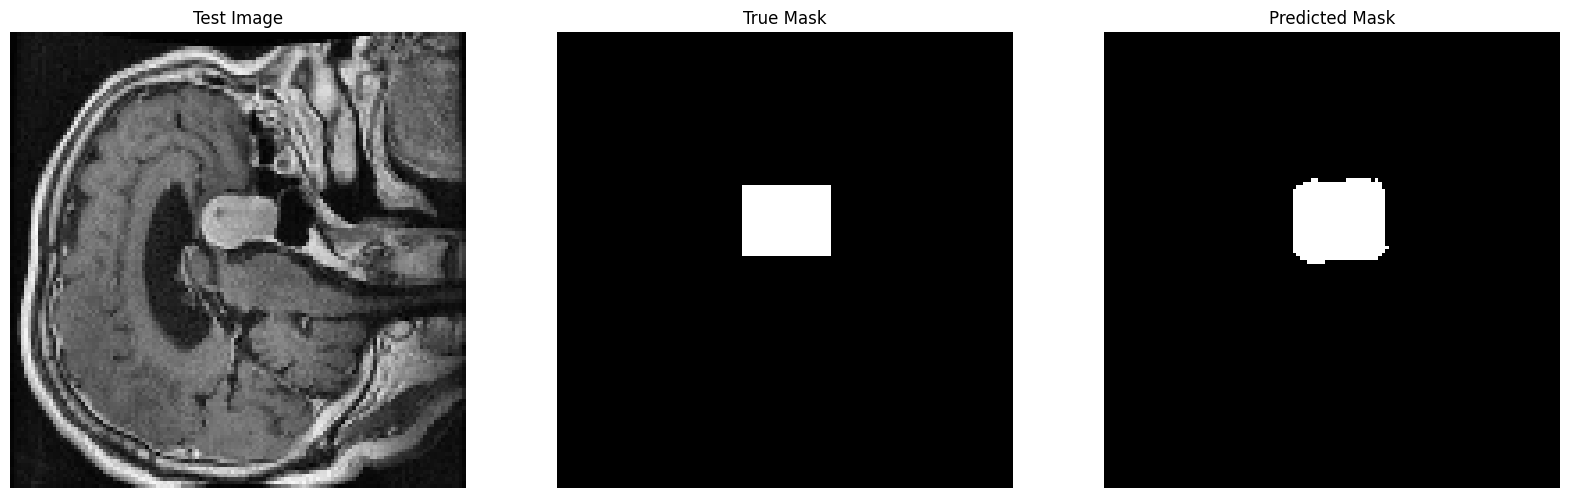

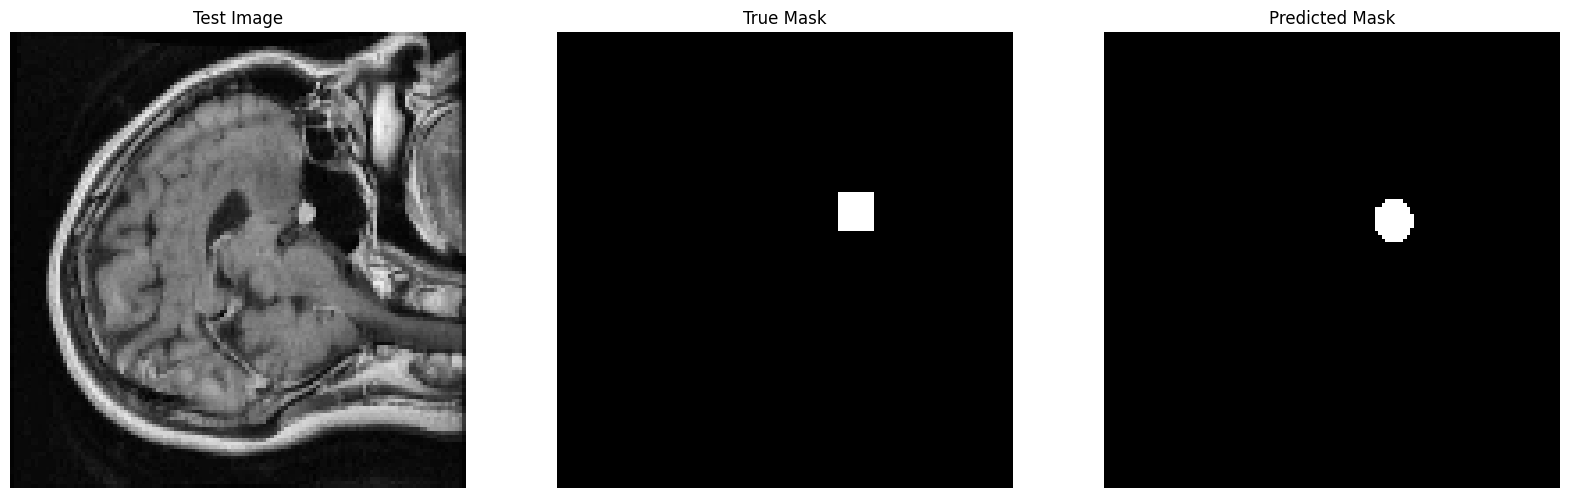

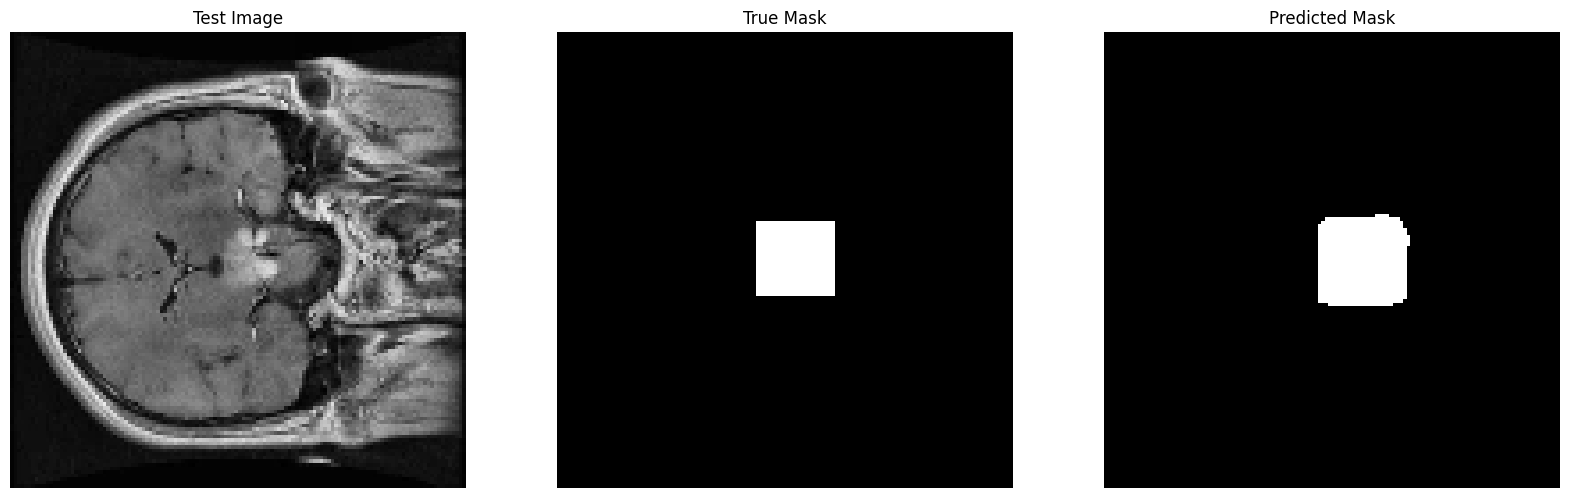

In [ ]:
plot_masked_images(DeepLpredicted_masks)

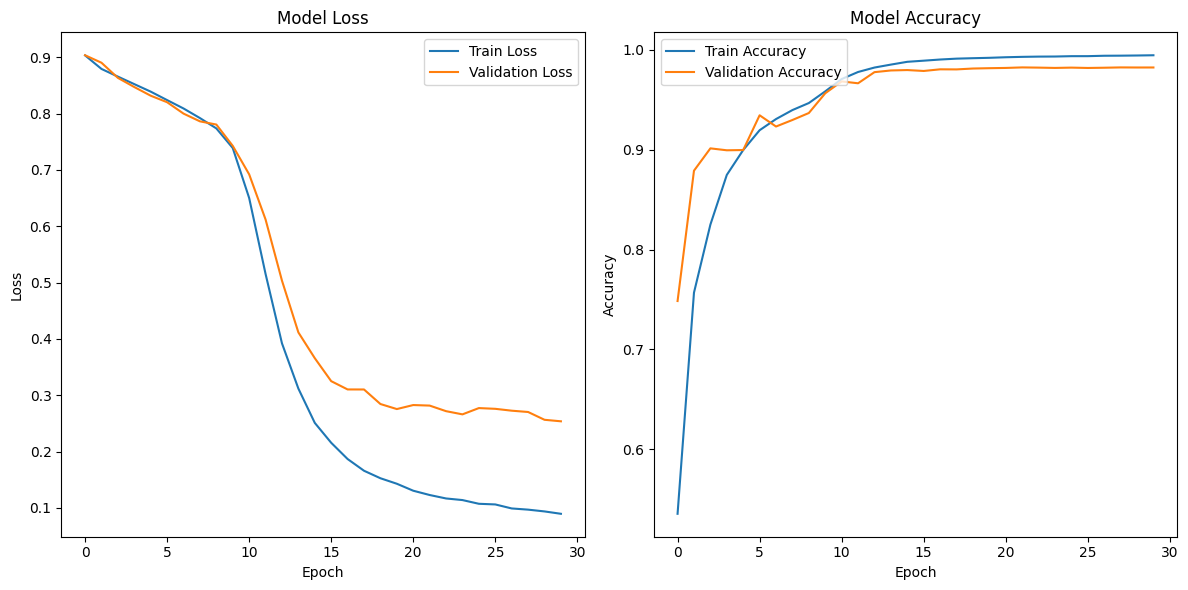

In [ ]:
plot_accuracy_loss_graph(DeepLhistory)

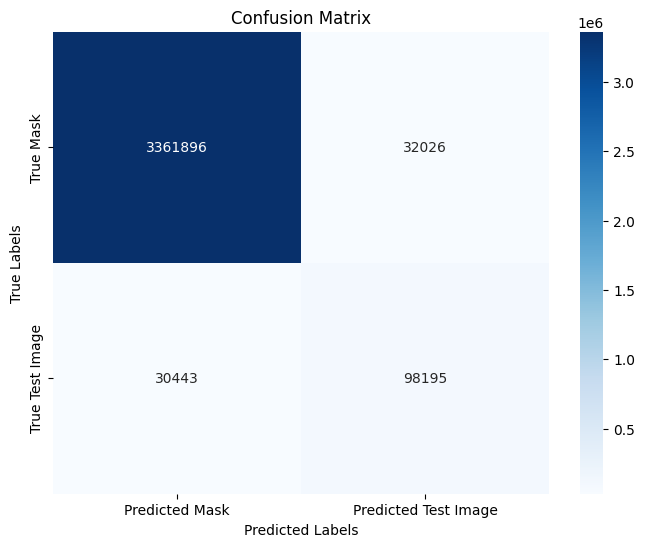

Precision: 0.7540642446302823
Recall: 0.7633436465119172
F1 Score: 0.7587


In [ ]:
calculate_evaluation_matrix(DeepLpredicted_masks)

In [ ]:

def fcn_model(input_shape):
    inputs = layers.Input(shape=input_shape)

    # Encoder: Convolutional layers with pooling
    conv1 = layers.Conv2D(64, (3, 3), padding='same', activation='relu')(inputs)
    conv1 = layers.Conv2D(64, (3, 3), padding='same', activation='relu')(conv1)
    pool1 = layers.MaxPooling2D((2, 2))(conv1)  # 256x256

    conv2 = layers.Conv2D(128, (3, 3), padding='same', activation='relu')(pool1)
    conv2 = layers.Conv2D(128, (3, 3), padding='same', activation='relu')(conv2)
    pool2 = layers.MaxPooling2D((2, 2))(conv2)  # 128x128

    conv3 = layers.Conv2D(256, (3, 3), padding='same', activation='relu')(pool2)
    conv3 = layers.Conv2D(256, (3, 3), padding='same', activation='relu')(conv3)
    pool3 = layers.MaxPooling2D((2, 2))(conv3)  # 64x64

    conv4 = layers.Conv2D(512, (3, 3), padding='same', activation='relu')(pool3)
    conv4 = layers.Conv2D(512, (3, 3), padding='same', activation='relu')(conv4)
    pool4 = layers.MaxPooling2D((2, 2))(conv4)  # 32x32

    conv5 = layers.Conv2D(1024, (3, 3), padding='same', activation='relu')(pool4)
    conv5 = layers.Conv2D(1024, (3, 3), padding='same', activation='relu')(conv5)  # 32x32

    # Upsampling and skip connections
    up6 = layers.Conv2DTranspose(512, (4, 4), strides=(2, 2), padding='same')(conv5)  # 64x64
    up6 = layers.add([up6, conv4])  # Combine with conv4 (64x64)

    up7 = layers.Conv2DTranspose(256, (4, 4), strides=(2, 2), padding='same')(up6)  # 128x128
    up7 = layers.add([up7, conv3])  # Combine with conv3 (128x128)

    up8 = layers.Conv2DTranspose(128, (4, 4), strides=(2, 2), padding='same')(up7)  # 256x256
    up8 = layers.add([up8, conv2])  # Combine with conv2 (256x256)

    up9 = layers.Conv2DTranspose(64, (4, 4), strides=(2, 2), padding='same')(up8)  # 512x512
    up9 = layers.add([up9, conv1])  # Combine with conv1 (512x512)

    # Final output layer
    outputs = layers.Conv2D(1, (1, 1), activation='sigmoid')(up9)

    # Create model
    model = models.Model(inputs, outputs, name='fcn_model')
    return model

# Example usage
input_shape = (128, 128, 3)
FCNmodel = fcn_model(input_shape)
FCNmodel.summary()


Model: "fcn_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2             │ (None, 128, 128, 3)    │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_12 (Conv2D)        │ (None, 128, 128, 64)   │          1,792 │ input_layer_2[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_13 (Conv2D)        │ (None, 128, 128, 64)   │         36,928 │ conv2d_12[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling2d             │ (None, 64, 64, 64)     │              0 │ conv2d_13[0][0]        │
│ (MaxPooling2D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_14 (Conv2D)        │ (None, 64, 64, 128)    │         73,856 │ max_pooling2d[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_15 (Conv2D)        │ (None, 64, 64, 128)    │        147,584 │ conv2d_14[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling2d_1           │ (None, 32, 32, 128)    │              0 │ conv2d_15[0][0]        │
│ (MaxPooling2D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_16 (Conv2D)        │ (None, 32, 32, 256)    │        295,168 │ max_pooling2d_1[0][0]  │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_17 (Conv2D)        │ (None, 32, 32, 256)    │        590,080 │ conv2d_16[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling2d_2           │ (None, 16, 16, 256)    │              0 │ conv2d_17[0][0]        │
│ (MaxPooling2D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_18 (Conv2D)        │ (None, 16, 16, 512)    │      1,180,160 │ max_pooling2d_2[0][0]  │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_19 (Conv2D)        │ (None, 16, 16, 512)    │      2,359,808 │ conv2d_18[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling2d_3           │ (None, 8, 8, 512)      │              0 │ conv2d_19[0][0]        │
│ (MaxPooling2D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_20 (Conv2D)        │ (None, 8, 8, 1024)     │      4,719,616 │ max_pooling2d_3[0][0]  │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_21 (Conv2D)        │ (None, 8, 8, 1024)     │      9,438,208 │ conv2d_20[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_transpose_3        │ (None, 16, 16, 512)    │      8,389,120 │ conv2d_21[0][0]        │
│ (Conv2DTranspose)         │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ add_12 (Add)         

 Total params: 29,985,345 (114.39 MB)

 Trainable params: 29,985,345 (114.39 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Compile the model
FCNmodel.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='binary_crossentropy',
    metrics=['accuracy', dice_coefficient]
)

In [ ]:
FCNhistory = FCNmodel.fit(
    train_image, train_mask,
    steps_per_epoch=len(train_image) // BATCH_SIZE,
    validation_data=(val_image, val_mask),
    epochs=30,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
        tf.keras.callbacks.ModelCheckpoint('FCN_best_model.keras', save_best_only=True)
    ]
)

Epoch 1/30
89/93 ━━━━━━━━━━━━━━━━━━━━ 1s 361ms/step - accuracy: 0.9621 - dice_coefficient: 0.0518 - loss: 0.3618

/usr/lib/python3.10/contextlib.py:153: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self.gen.throw(typ, value, traceback)


93/93 ━━━━━━━━━━━━━━━━━━━━ 101s 752ms/step - accuracy: 0.9622 - dice_coefficient: 0.0531 - loss: 0.3557 - val_accuracy: 0.9633 - val_dice_coefficient: 0.1262 - val_loss: 0.1186
Epoch 2/30
93/93 ━━━━━━━━━━━━━━━━━━━━ 31s 329ms/step - accuracy: 0.9632 - dice_coefficient: 0.1548 - loss: 0.1110 - val_accuracy: 0.9633 - val_dice_coefficient: 0.1667 - val_loss: 0.1102
Epoch 3/30
93/93 ━━━━━━━━━━━━━━━━━━━━ 27s 182ms/step - accuracy: 0.9644 - dice_coefficient: 0.1719 - loss: 0.1035 - val_accuracy: 0.9633 - val_dice_coefficient: 0.1801 - val_loss: 0.1122
Epoch 4/30
93/93 ━━━━━━━━━━━━━━━━━━━━ 32s 306ms/step - accuracy: 0.9635 - dice_coefficient: 0.1934 - loss: 0.1038 - val_accuracy: 0.9637 - val_dice_coefficient: 0.2293 - val_loss: 0.0970
Epoch 5/30
93/93 ━━━━━━━━━━━━━━━━━━━━ 32s 210ms/step - accuracy: 0.9652 - dice_coefficient: 0.2434 - loss: 0.0956 - val_accuracy: 0.9652 - val_dice_coefficient: 0.2450 - val_loss: 0.0950
Epoch 6/30
93/93 ━━━━━━━━━━━━━━━━━━━━ 31s 329ms/step - accuracy: 0.9674 - d

In [ ]:
#test_image, test_mask = preprocess_data(test_image, test_mask, target_size=(IMG_HEIGHT, IMG_WIDTH))
FCNtest_loss, FCNtest_accuracy, dice_loss = FCNmodel.evaluate(test_image, test_mask, verbose=1)
print(f"Test Loss: {FCNtest_loss}")
print(f"Test Accuracy: {FCNtest_accuracy}")


7/7 ━━━━━━━━━━━━━━━━━━━━ 13s 2s/step - accuracy: 0.9790 - dice_coefficient: 0.6404 - loss: 0.0563
Test Loss: 0.05604888126254082
Test Accuracy: 0.978783905506134


In [ ]:
# Predict masks on the test set
FCNpredicted_masks = FCNmodel.predict(test_image)

FCNpredicted_masks = (FCNpredicted_masks > threshold).astype(np.uint8)

7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 107ms/step


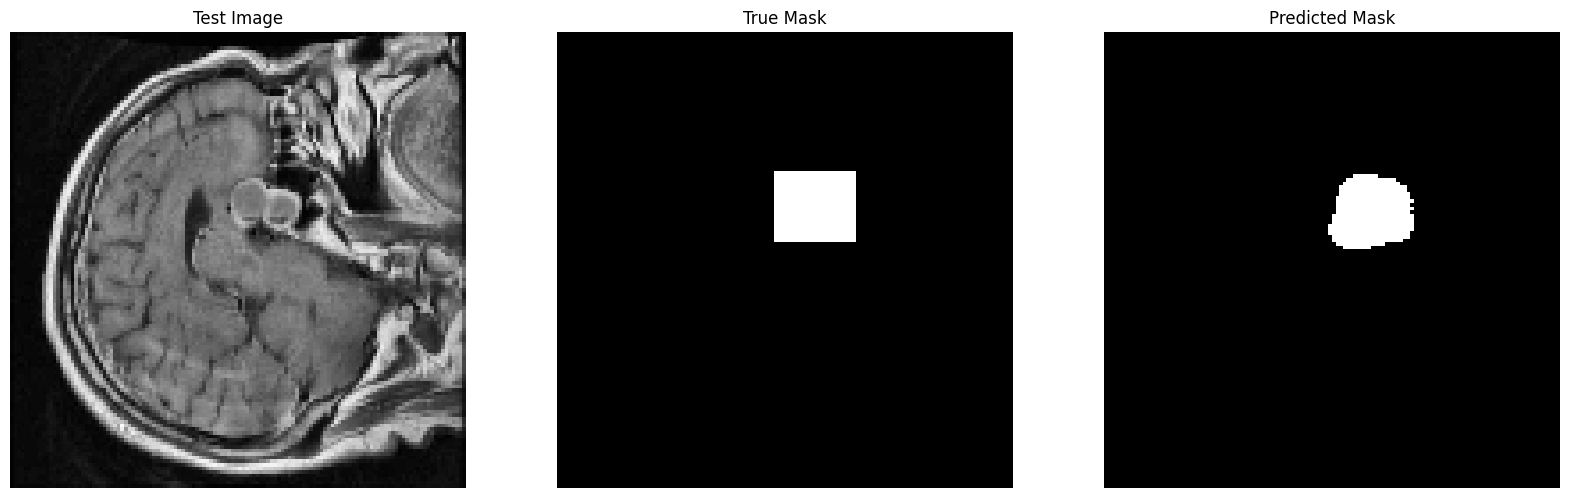

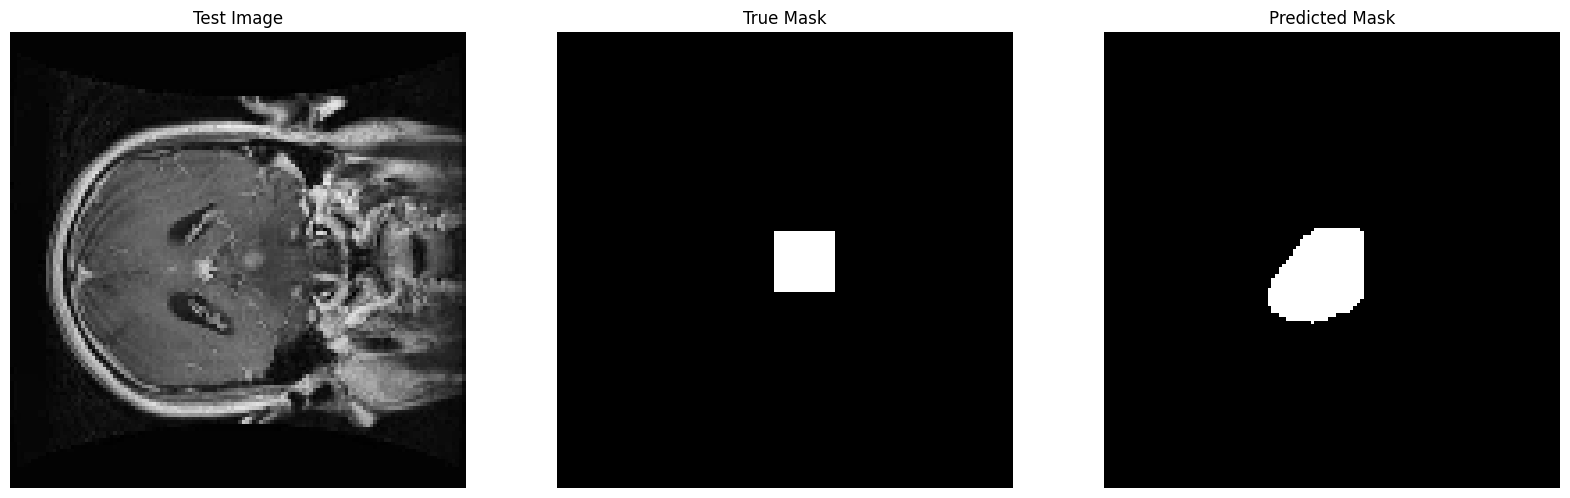

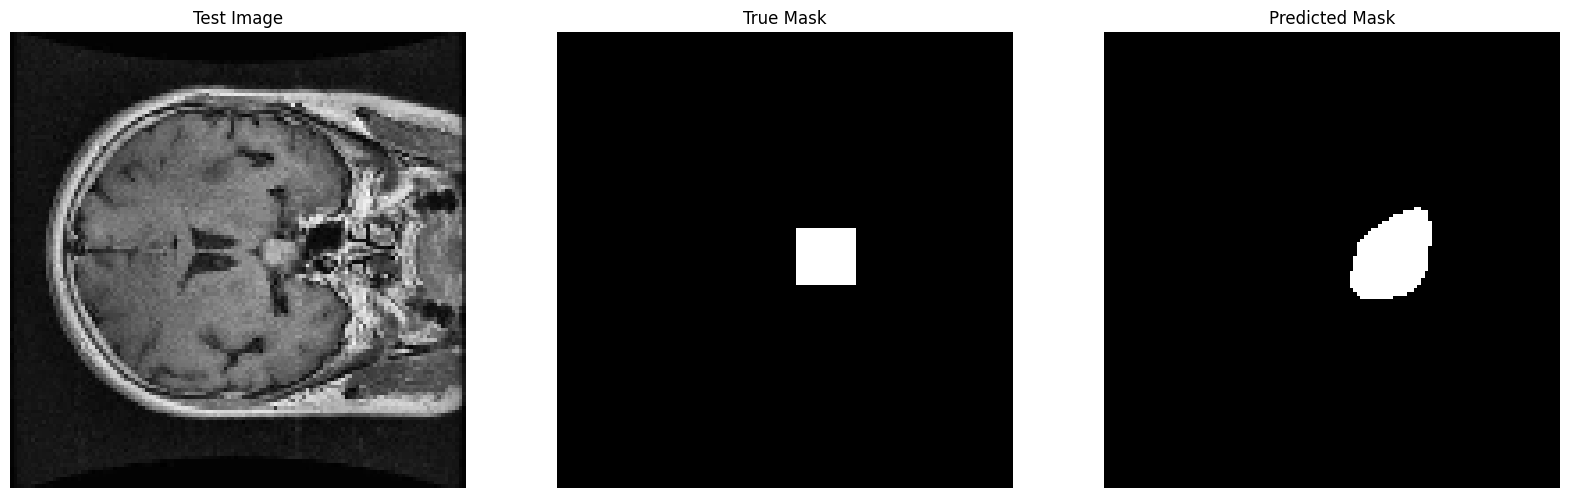

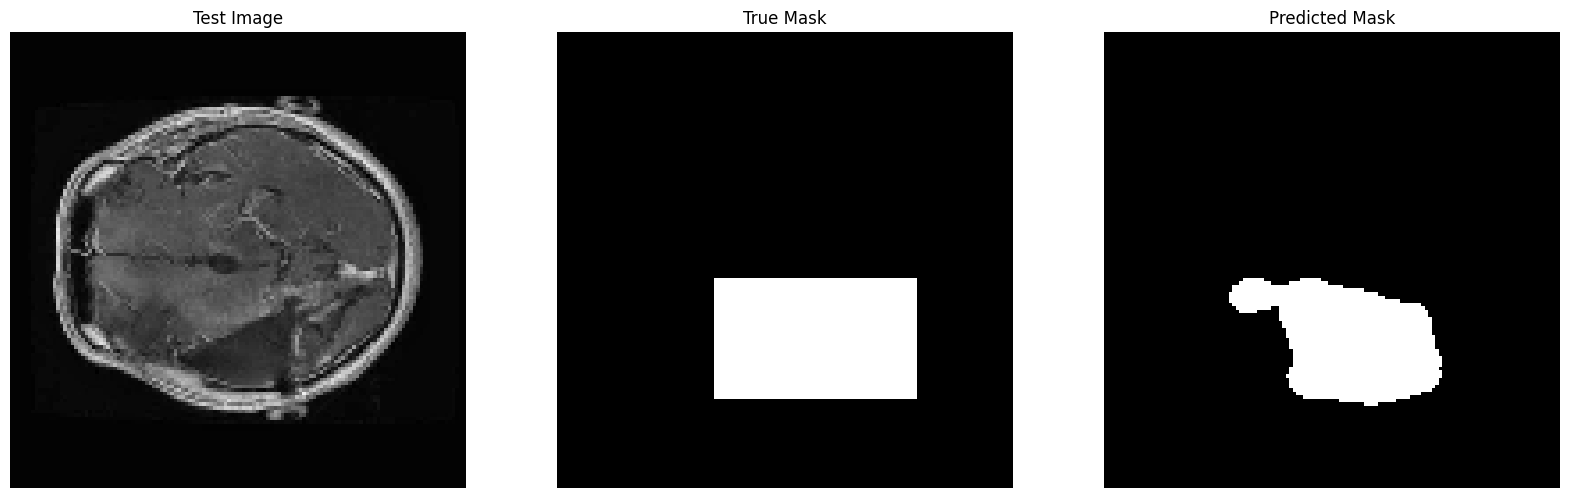

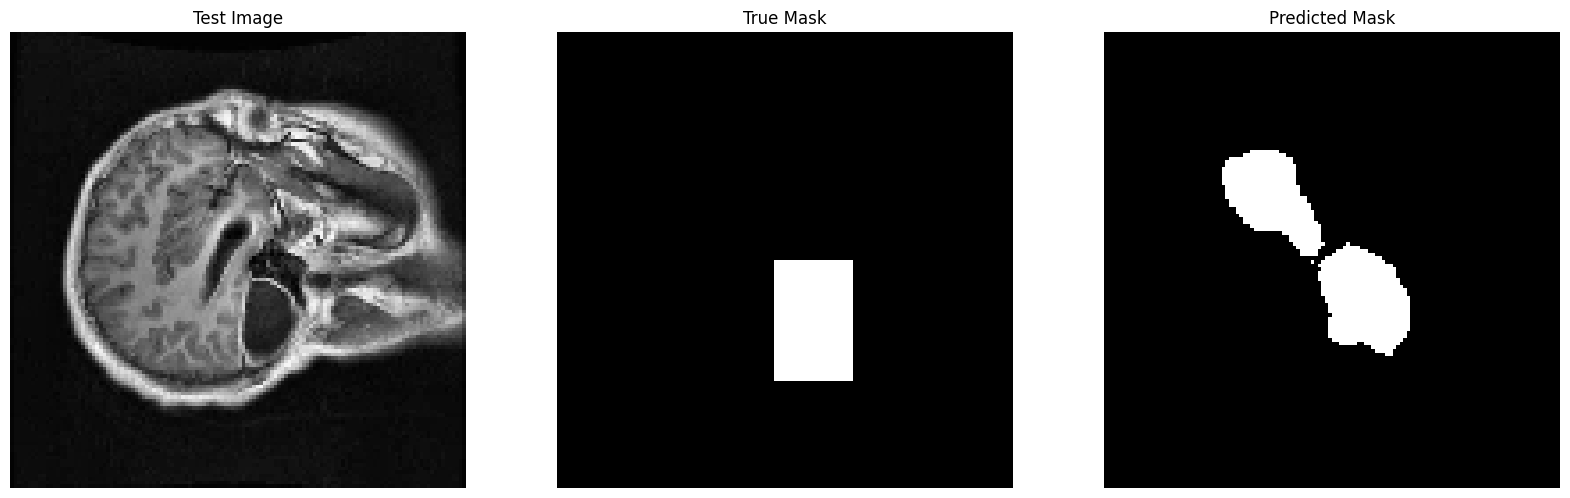

In [ ]:
plot_masked_images(FCNpredicted_masks)

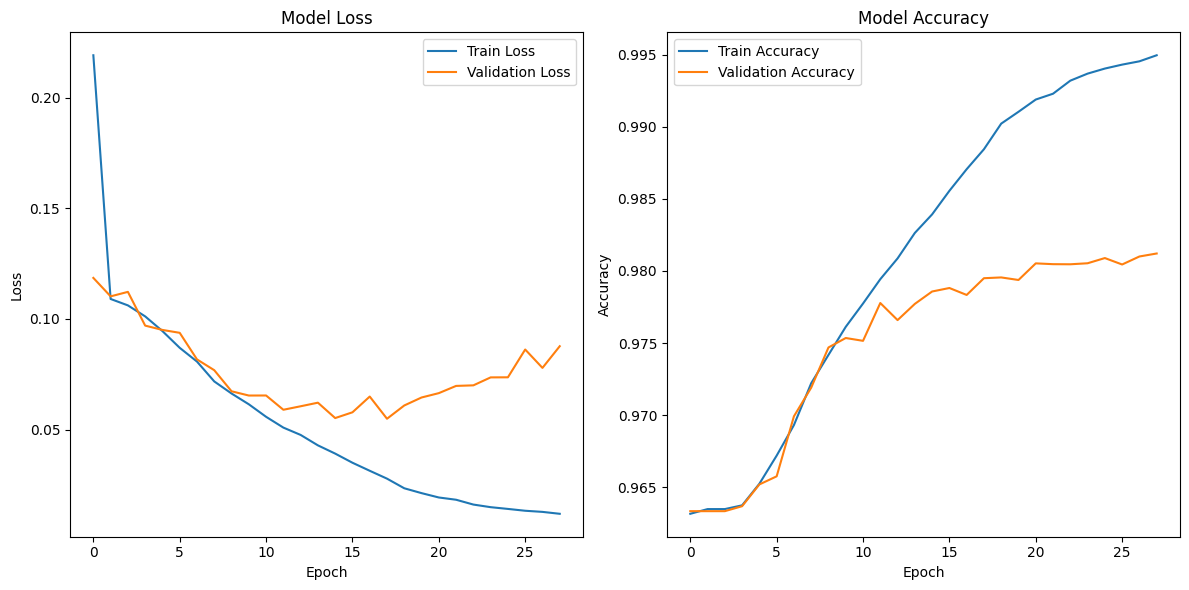

In [ ]:
plot_accuracy_loss_graph(FCNhistory)

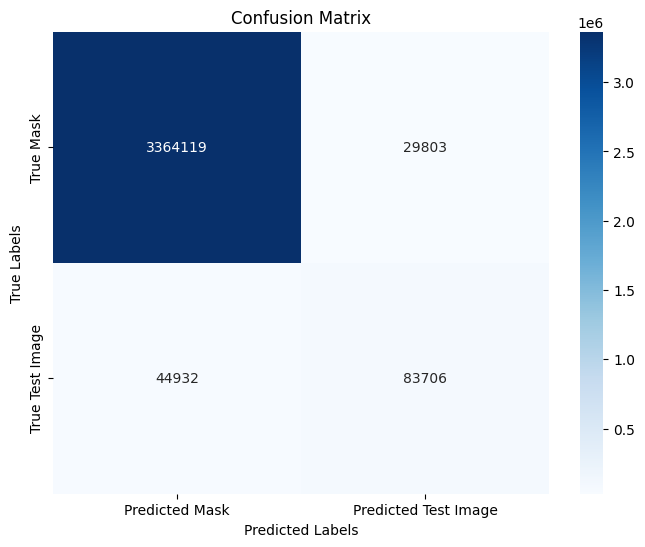

Precision: 0.7374393219920887
Recall: 0.6507097436216359
F1 Score: 0.6914


In [ ]:
calculate_evaluation_matrix(FCNpredicted_masks)